In [58]:
%load_ext autoreload
%autoreload 2
import os
import matplotlib.pyplot as plt
import seaborn as sns
from os.path import join
from tqdm import tqdm
import pandas as pd
import sys
from IPython.display import display, HTML
from typing import List
import numpy as np
from copy import deepcopy
# import sasc.notebook_helper
import neuro.sasc.viz
import scipy.special
from collections import defaultdict
from pprint import pprint
import neuro.sasc.analyze_helper
import joblib
# import viz
# from sasc.config import RESULTS_DIR
from neuro.config import STORIES_DIR_GCT
import dvu
dvu.set_style()

# setting = 'default'
setting = 'roi_steered/no_continuity'
MAIN_DIR = join(STORIES_DIR_GCT, setting)
EXPT_DIRS = sorted([join(MAIN_DIR, dir_name) for dir_name in os.listdir(MAIN_DIR)])
# EXPT_DIRS = [x for x in EXPT_DIRS if 'uts03' in x.lower() or 'uts01' in x.lower()]
EXPT_DIRS = [x for x in EXPT_DIRS if 'uts02' in x.lower()]
# EXPT_DIRS = [x for x in EXPT_DIRS if 'uts01' in x.lower()]
EXPT_DIR = EXPT_DIRS[0]
os.makedirs('heatmaps_repr_steering', exist_ok=True)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Averaged heatmaps

### Process encoding score averaged across stories

In [66]:
dfs_dict = {}
mat_dict = {}
subject = 'uts02'
for setting in [
    'roi_steered/naive_reg',
    'roi_steered/less_reg',
    'roi_steered/less_reg_more_temp',
    'roi_steered/less_reg_more_temp_add_gpt5',
    'roi_steered/no_continuity',
    'roi']:
    MAIN_DIR = join(STORIES_DIR_GCT, setting)
    EXPT_DIRS = sorted([join(MAIN_DIR, dir_name)
                    for dir_name in os.listdir(MAIN_DIR)])
    mats = []
    expt_dirs = [x for x in EXPT_DIRS if subject in x]
    res = {}

    for expt_dir in expt_dirs:
        try:
            scores_data = joblib.load(
                join(expt_dir, f"scores_mod_ngram_length={0}.pkl"))
            s = scores_data["scores_mean"].T
            # z-score each column
            s = (s - s.mean(axis=0)) / s.std(axis=0)
            s = s.T
            try:
                rows = joblib.load(join(expt_dir, f"rows.pkl"))
            except:
                rows = pd.read_csv(join(expt_dir, f"rows.csv"))
            expls = rows.expl.values
            roi = rows.roi.values
            expls_order = np.argsort(expls)
            s = s[expls_order][:, expls_order]  # [:, expls_order]
            expls = expls[expls_order]
            roi = roi[expls_order]
            mats.append(s)

        except Exception as e:
            print(f"Error loading {expt_dir}: {e}")

    # compute avg
    mat = np.array(mats).mean(axis=0)
    mat_diffs = []
    for i in range(mat.shape[0]):
        mat_diffs.append(
            mat[i][i] - (mat[i].sum() - mat[i][i]) / (mat.shape[0] - 1)
        )

    # drop row and col for which expl = START or expl = END
    valid_indices = [i for i, expl in enumerate(
        expls) if expl not in ['START', 'END']]
    mat = mat[np.ix_(valid_indices, valid_indices)]
    expls = [expls[i] for i in valid_indices]
    roi = [roi[i] for i in valid_indices]
    mat_diffs = [mat_diffs[i] for i in valid_indices]


    df = pd.DataFrame(mat_diffs, columns=['encoding_score'])
    df['expl'] = expls
    df['subject'] = subject
    df['roi'] = roi
    df['setting'] = setting
    df['mat_diff'] = mat_diffs
    dfs_dict[setting] = df
    mat_dict[subject] = mat

    # visualize
    s = mat
    # neuro.sasc.viz.heatmap(
    #     s, expls, ylab="Voxel explanation",
    #     xlab="Driving paragraph", label_fontsize='large', clab='Mean model response ($\sigma$)')
    # neuro.sasc.viz.outline_diagonal(s.shape, color='black', lw=1, block_size=1)
    labs = [f'{i + 1:02d}' for i in range(len(expls))]
    fontsize = 'medium'
    # expls = expls[expls_order]
    # plt.yticks(labels=expls, ticks=np.arange(
    #     len(labs)), fontsize=fontsize)
    # plt.xticks(labels=expls, ticks=np.arange(
    #     len(labs)), rotation=90, fontsize=fontsize)

    # plt.savefig(join('heatmaps_repr_steering', f'encoding_heatmap_avg_{subject}.pdf'), bbox_inches="tight")
    # plt.show()

Error loading /home/chansingh/automated-brain-explanations/results/gct_stories/roi/uts02___roi_may31___seed=3: [Errno 2] No such file or directory: '/home/chansingh/automated-brain-explanations/results/gct_stories/roi/uts02___roi_may31___seed=3/scores_mod_ngram_length=0.pkl'
Error loading /home/chansingh/automated-brain-explanations/results/gct_stories/roi/uts02___roi_may31___seed=4: [Errno 2] No such file or directory: '/home/chansingh/automated-brain-explanations/results/gct_stories/roi/uts02___roi_may31___seed=4/scores_mod_ngram_length=0.pkl'
Error loading /home/chansingh/automated-brain-explanations/results/gct_stories/roi/uts02___roi_nov30___seed=1: [Errno 2] No such file or directory: '/home/chansingh/automated-brain-explanations/results/gct_stories/roi/uts02___roi_nov30___seed=1/scores_mod_ngram_length=0.pkl'
Error loading /home/chansingh/automated-brain-explanations/results/gct_stories/roi/uts02___roi_nov30___seed=2: [Errno 2] No such file or directory: '/home/chansingh/automat

/usr/lib/python3.12/pickle.py:323: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use the public NumPy API. If not, you are using NumPy internals. If you would still like to access an internal attribute, use numpy._core.numeric._frombuffer.
  obj = getattr(obj, subpath)
/usr/lib/python3.12/pickle.py:323: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use

In [67]:
# pandas join all dfs in values of dfs_dict.values()
df_mega = pd.concat(dfs_dict.values(), ignore_index=True)

<>:32: SyntaxWarning: invalid escape sequence '\s'
<>:32: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_4116431/143505395.py:32: SyntaxWarning: invalid escape sequence '\s'
  plt.ylabel('Encoding model\ndriving score ($\sigma$)')
/tmp/ipykernel_4116431/143505395.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


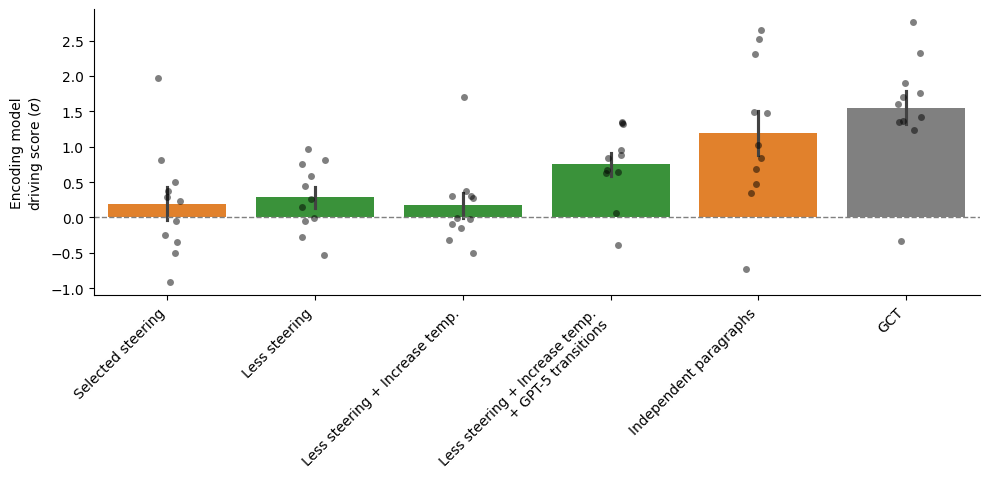

In [92]:
# set colors of bars
cs = ['C1', 'C2',
    'C2',
    'C2',
    'C1',
    'gray',
]
plt.figure(figsize=(10, 5))
sns.barplot(
    data=df_mega, x='setting', y='mat_diff', errorbar='se',
    palette=cs,
    # ci='se', capsize=0.2
)
sns.stripplot(
    data=df_mega, x='setting', y='mat_diff',
    color='black', alpha=0.5, jitter=True
)

# rotate xlabs vertically
plt.xticks(rotation=45,
           ticks=np.arange(6),
           # right align
            ha='right',
           labels=[
    'Selected steering',
    'Less steering',
    'Less steering + Increase temp.',
    'Less steering + Increase temp.\n+ GPT-5 transitions',
    'Independent paragraphs',
    'GCT',
])
plt.ylabel('Encoding model\ndriving score ($\sigma$)')
plt.xlabel('')
plt.axhline(0, color='gray', linestyle='--', linewidth=1)
plt.tight_layout()
plt.savefig(join('heatmaps_repr_steering', f'encoding_heatmap_avg_all_settings_{subject}.pdf'), bbox_inches="tight")
plt.show()

<>:12: SyntaxWarning: invalid escape sequence '\s'
<>:12: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_4116431/3079367133.py:12: SyntaxWarning: invalid escape sequence '\s'
  xlab="Driving paragraph", label_fontsize='large', clab='Mean model response ($\sigma$)')


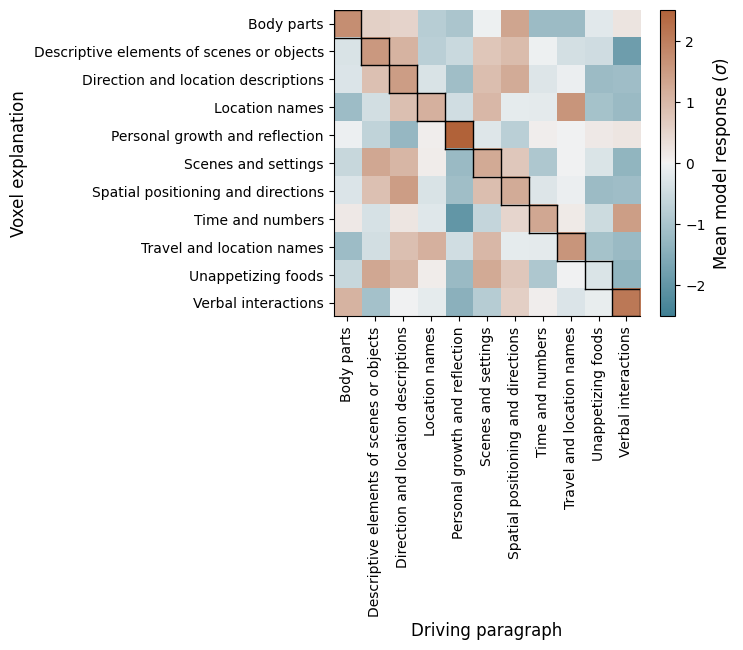

In [93]:
# expls_order = sasc.analyze_helper.sort_expls_semantically(expls)
# expls_order = idx_order
for subject in ['uts02']:
    # expls = expls_dict[subject]
    # mat = mat_dict[subject]

    # expls_order = [15, 7, 11, 14, 3, 12, 4, 1, 2, 0, 13, 6, 5, 16, 10, 9, 8]
    # s = mat[expls_order][:, expls_order]  # [:, expls_order]
    s = mat
    neuro.sasc.viz.heatmap(
        s, expls, ylab="Voxel explanation",
        xlab="Driving paragraph", label_fontsize='large', clab='Mean model response ($\sigma$)')
    neuro.sasc.viz.outline_diagonal(s.shape, color='black', lw=1, block_size=1)
    labs = [f'{i + 1:02d}' for i in range(len(expls))]
    fontsize = 'medium'
    # expls = expls[expls_order]
    plt.yticks(labels=expls, ticks=np.arange(
        len(labs)), fontsize=fontsize)
    plt.xticks(labels=expls, ticks=np.arange(
        len(labs)), rotation=90, fontsize=fontsize)

    plt.savefig(join('heatmaps_repr_steering', f'encoding_heatmap_avg_{subject}.pdf'), bbox_inches="tight")
    plt.show()